# FIT5149 S2 2026 — Предсказание санкционированной суммы

Этот ноутбук содержит полный процесс моделирования для соревнования Kaggle.

## Цель проекта

Предсказать `sanctioned_amount_aud` для каждой заявки на кредит.

Целевая переменная содержит значительную долю нулевых значений, поэтому задача рассматривается как **гибридная задача прогнозирования**:

1. **Классификатор нулевого/положительного значения** — оценивает вероятность положительной санкционированной суммы.
2. **Ratio-модель** — оценивает отношение санкционированной суммы к запрошенной для положительных случаев.
3. **Условная log-регрессия** — предсказывает санкционированную сумму среди положительных заявок.
4. **Прямая регрессия** — непосредственно предсказывает целевую переменную.
5. **Ансамбль** — объединяет прогнозы разных моделей.
6. **Оптимизация порога** — использует валидационную выборку для выбора рабочего порога.


In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error,
    roc_auc_score,
    mean_absolute_error,
)
import xgboost as xgb

SEED = 47
TARGET = "sanctioned_amount_aud"

DATA_DIR = Path("data")
TRAIN_PATH = DATA_DIR / "training_set.csv"
TEST_PATH = DATA_DIR / "kaggle_test_X.csv"
SAMPLE_PATH = DATA_DIR / "sample_submission.csv"

print("Версия XGBoost:", xgb.__version__)
print("Train:", TRAIN_PATH)
print("Test :", TEST_PATH)

Версия XGBoost: 3.4.1
Train: data\training_set.csv
Test : data\kaggle_test_X.csv


In [2]:
train_raw = pd.read_csv(TRAIN_PATH)
test_raw = pd.read_csv(TEST_PATH)
sample_submission = pd.read_csv(SAMPLE_PATH)

print(f"Размер train: {train_raw.shape}")
print(f"Размер test : {test_raw.shape}")
print(f"Target: {TARGET}")

display(train_raw.head())

Размер train: (19322, 29)
Размер test : (10000, 28)
Target: sanctioned_amount_aud


,application_id,applicant_gender,applicant_age,annual_income_aud,income_consistency,occupation_class,employment_sector,residence_area,requested_amount_aud,existing_repayments_aud,...,property_area,has_co_applicant,property_value_aud,marketing_channel,branch_id,application_date,monthly_income_aud,risk_review_flag,enquiry_count_12m,sanctioned_amount_aud
0,LN-000002,male,65,3572.42,steady,retiree,NaN,outer_metro,80823.31,369.81,...,NaN,1,118370.54,online,BR111,30/11/2024,290.87,1,3,56576.32
1,LN-000003,male,48,NaN,variable,salaried,retail,outer_metro,41673.08,188.25,...,regional,0,47000.08,online,BR110,25/09/2023,NaN,0,4,0.00
2,LN-000005,female,18,3551.48,variable,salaried,retail,outer_metro,199076.75,941.27,...,outer_metro,1,277686.30,online,BR164,13/09/2024,286.62,0,4,149307.56
3,LN-000006,male,50,NaN,variable,commercial_partner,retail,inner_metro,120176.89,309.71,...,outer_metro,1,203173.22,online,BR051,25/07/2023,NaN,1,3,78114.98
4,LN-000007,male,28,NaN,NaN,salaried,NaN,outer_metro,62745.53,454.49,...,regional,1,86636.21,branch_walkin,BR072,13/12/2024,NaN,1,2,50196.42


## 2. Первичный анализ данных

Исходный обучающий набор содержит 29 столбцов, включая target. В нескольких числовых признаках есть пропуски, а также специальные значения-маркеры, например `-999`.

Ниже эти значения обрабатываются явно, чтобы они не интерпретировались как реальные финансовые суммы.

In [26]:
display(train_raw.info())
display(train_raw.describe(include="all").T)

missing = (train_raw.isna().mean().sort_values(ascending=False).to_frame("missing_rate"))

display(missing.head(15))

print("\nTarget summary:")
display(train_raw[TARGET].describe())

zero_rate = (train_raw[TARGET] == 0).mean()
print(f"Доля нулевых target: {zero_rate:.2%}")

<class 'pandas.DataFrame'>
RangeIndex: 19322 entries, 0 to 19321
Data columns (total 29 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   application_id           19322 non-null  str    
 1   applicant_gender         19295 non-null  str    
 2   applicant_age            19322 non-null  int64  
 3   annual_income_aud        14474 non-null  float64
 4   income_consistency       18245 non-null  str    
 5   occupation_class         19322 non-null  str    
 6   employment_sector        14616 non-null  str    
 7   residence_area           19322 non-null  str    
 8   requested_amount_aud     19322 non-null  float64
 9   existing_repayments_aud  17028 non-null  float64
 10  expense_flag_a           19322 non-null  str    
 11  expense_flag_b           19322 non-null  str    
 12  dependants_count         17746 non-null  float64
 13  credit_rating            15369 non-null  float64
 14  prior_default_count      19322 no

None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
application_id,19322,19322,LN-000002,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
applicant_gender,19295,2,male,9687,NaN,NaN,NaN,NaN,NaN,NaN,NaN
applicant_age,19322.0,NaN,NaN,NaN,40.241331,16.034623,18.0,25.0,40.0,55.0,65.0
annual_income_aud,14474.0,NaN,NaN,NaN,4165.233997,23054.615632,585.43,2551.84,3411.835,4789.175,2755063.33
income_consistency,18245,2,variable,16571,NaN,NaN,NaN,NaN,NaN,NaN,NaN
occupation_class,19322,8,salaried,10918,NaN,NaN,NaN,NaN,NaN,NaN,NaN
employment_sector,14616,18,labouring,3622,NaN,NaN,NaN,NaN,NaN,NaN,NaN
residence_area,19322,3,outer_metro,13939,NaN,NaN,NaN,NaN,NaN,NaN,NaN
requested_amount_aud,19322.0,NaN,NaN,NaN,137378.44282,92226.888472,9467.48,63680.7425,116439.51,185040.44,933695.43
existing_repayments_aud,17028.0,NaN,NaN,NaN,607.119941,357.02745,-999.0,369.8975,563.97,780.76,5953.36


,missing_rate
property_age_years,0.323983
monthly_income_aud,0.256857
annual_income_aud,0.250906
employment_sector,0.243557
credit_rating,0.204585
existing_repayments_aud,0.118725
dependants_count,0.081565
property_value_aud,0.060967
income_consistency,0.055740
property_area,0.011334



Target summary:


count     19322.000000
mean      74850.411246
std       74939.040644
min           0.000000
25%           0.000000
50%       55898.160000
75%      116108.227500
max      746956.350000
Name: sanctioned_amount_aud, dtype: float64

Доля нулевых target: 26.79%


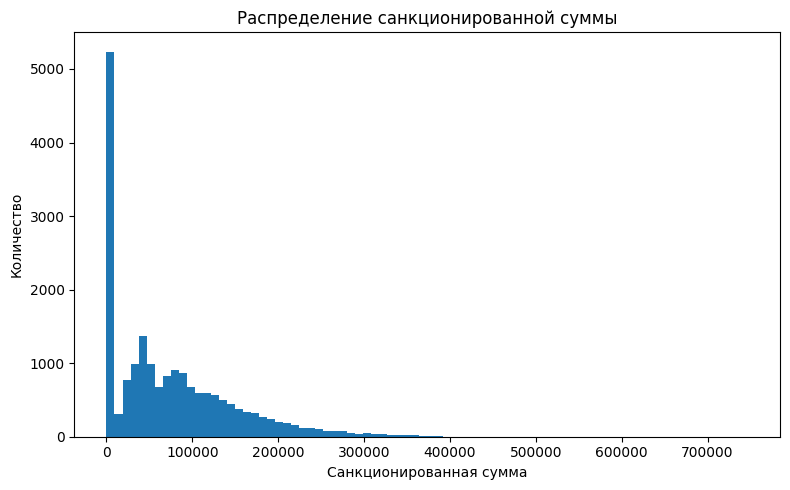

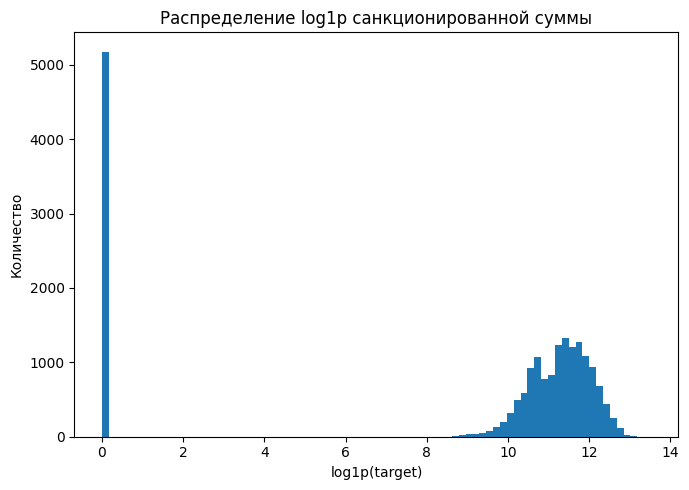

In [4]:
# TARGET

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(train_raw[TARGET], bins=80)
ax.set_title("Распределение санкционированной суммы")
ax.set_xlabel("Санкционированная сумма")
ax.set_ylabel("Количество")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(np.log1p(train_raw[TARGET]), bins=80)
ax.set_title("Распределение log1p санкционированной суммы")
ax.set_xlabel("log1p(target)")
ax.set_ylabel("Количество")
plt.tight_layout()
plt.show()

## 4. Очистка данных и создание признаков

Основные решения:

- `application_id` является идентификатором и удаляется.
- `branch_id` также рассматривается как идентификатор, а не как числовой предиктор.
- `property_ref` является кодом-ссылкой и удаляется вместо интерпретации как непрерывного числа.
- `application_date` преобразуется в календарные признаки **до** удаления исходной даты.
- специальные значения `-999` преобразуются в пропуски там, где они обозначают отсутствие или неизвестность информации.
- для нескольких важных числовых признаков сохраняются индикаторы пропусков.
- для финансовых признаков создаются логарифмические версии, поскольку их распределения сильно скошены.
- из исходных переменных создаются относительные и взаимодействующие признаки.
- признаки, зависящие от target, не используются.

In [5]:
# FEATURE ENGINEERING

SENTINEL_TO_NAN = [
    "existing_repayments_aud",
    "property_value_aud",
    "has_co_applicant",
]

def make_features(df):
    d = df.copy()
    if "application_date" in d.columns:
        dt = pd.to_datetime(
            d["application_date"],
            format="%d/%m/%Y",
            errors="coerce"
        )
        d["app_year"] = dt.dt.year
        d["app_month"] = dt.dt.month
        d["app_quarter"] = dt.dt.quarter
        d["app_dayofweek"] = dt.dt.dayofweek
        d["app_day"] = dt.dt.day
        d["app_is_weekend"] = (dt.dt.dayofweek >= 5).astype("float")
        d = d.drop(columns=["application_date"])


    for col in SENTINEL_TO_NAN:
        if col in d.columns:
            d[col] = d[col].replace(-999, np.nan)


    financial_cols = [
        "annual_income_aud",
        "monthly_income_aud",
        "requested_amount_aud",
        "existing_repayments_aud",
        "property_value_aud",
        "property_age_years",
    ]
    for col in financial_cols:
        if col in d.columns:
            d[col] = pd.to_numeric(d[col], errors="coerce")
            d.loc[d[col] < 0, col] = np.nan


    for col in ["application_id", "branch_id", "property_ref"]:
        if col in d.columns:
            d = d.drop(columns=[col])


    missing_cols = [
        "annual_income_aud",
        "monthly_income_aud",
        "existing_repayments_aud",
        "credit_rating",
        "property_age_years",
        "property_value_aud",
        "dependants_count",
    ]

    for col in missing_cols:
        if col in d.columns:
            d[f"{col}_missing"] = d[col].isna().astype(np.int8)


    # Признаки возраста

    if "applicant_age" in d.columns:
        age = pd.to_numeric(d["applicant_age"], errors="coerce")
        d["age_sq"] = age ** 2
        d["age_log"] = np.log1p(age.clip(lower=0))
        d["age_18_25"] = ((age >= 18) & (age <= 25)).astype(np.int8)
        d["age_26_35"] = ((age >= 26) & (age <= 35)).astype(np.int8)
        d["age_36_50"] = ((age >= 36) & (age <= 50)).astype(np.int8)
        d["age_51_plus"] = (age >= 51).astype(np.int8)

    # Признаки кредитного рейтинга

    if "credit_rating" in d.columns:
        credit = pd.to_numeric(d["credit_rating"], errors="coerce")
        d["credit_sq"] = credit ** 2
        d["credit_cube"] = credit ** 3
        d["credit_low"] = (credit <= 650).astype(np.int8)
        d["credit_medium"] = ((credit > 650) & (credit <= 800)).astype(np.int8)
        d["credit_high"] = (credit > 800).astype(np.int8)

    # --------------------------------------------------------
    # Логарифмические версии скошенных финансовых признаков
    # --------------------------------------------------------
    log_cols = [
        "annual_income_aud",
        "monthly_income_aud",
        "requested_amount_aud",
        "existing_repayments_aud",
        "property_value_aud",
        "property_age_years",
    ]

    for col in log_cols:
        if col in d.columns:
            x = pd.to_numeric(d[col], errors="coerce")
            d[f"{col}_log"] = np.log1p(x.clip(lower=0))

    eps = 1e-6

    # Связи между запрошенной суммой и доходом
    if {"monthly_income_aud", "requested_amount_aud"}.issubset(d.columns):
        income = pd.to_numeric(d["monthly_income_aud"], errors="coerce").clip(lower=0)
        request = pd.to_numeric(d["requested_amount_aud"], errors="coerce").clip(lower=0)

        d["income_to_request"] = income / (request + eps)
        d["request_to_income"] = request / (income + eps)
        d["request_income_gap"] = income - request
        d["request_income_logratio"] = np.log1p(request) - np.log1p(income)
        d["request_months_income"] = request / (income + eps)


    # Связи между выплатами и доходом
    if {"existing_repayments_aud", "monthly_income_aud"}.issubset(d.columns):
        repayment = pd.to_numeric(
            d["existing_repayments_aud"], errors="coerce"
        ).clip(lower=0)
        income = pd.to_numeric(
            d["monthly_income_aud"], errors="coerce"
        ).clip(lower=0)

        d["repayment_to_income"] = repayment / (income + eps)
        d["income_after_repayment"] = income - repayment
        d["net_income_ratio"] = (income - repayment) / (income + eps)
        d["income_to_repayment"] = income / (repayment + eps)
        d["dti"] = repayment / (income + eps)
        d["dti_high"] = (d["dti"] > 0.50).astype(np.int8)


    # Связи между стоимостью недвижимости и запрошенной суммой
    if {"requested_amount_aud", "property_value_aud"}.issubset(d.columns):
        request = pd.to_numeric(
            d["requested_amount_aud"], errors="coerce"
        ).clip(lower=0)
        prop = pd.to_numeric(
            d["property_value_aud"], errors="coerce"
        ).clip(lower=0)

        d["request_to_property"] = request / (prop + eps)
        d["property_minus_request"] = prop - request
        d["property_to_request"] = prop / (request + eps)
        d["ltv"] = request / (prop + eps)
        d["ltv_bin"] = pd.cut(
            d["ltv"],
            bins=[-np.inf, 0.60, 0.80, 0.95, 1.00, np.inf],
            labels=False
        )


    # Связи между недвижимостью и доходом
    if {"property_value_aud", "monthly_income_aud"}.issubset(d.columns):
        prop = pd.to_numeric(
            d["property_value_aud"], errors="coerce"
        ).clip(lower=0)
        income = pd.to_numeric(
            d["monthly_income_aud"], errors="coerce"
        ).clip(lower=0)

        d["property_to_income"] = prop / (income + eps)
        d["income_to_property"] = income / (prop + eps)

    # Взаимодействия признаков
    if "credit_rating" in d.columns:
        credit = pd.to_numeric(d["credit_rating"], errors="coerce")

        if "monthly_income_aud" in d.columns:
            income = pd.to_numeric(
                d["monthly_income_aud"], errors="coerce"
            ).clip(lower=0)
            d["credit_x_income_log"] = credit * np.log1p(income)

        if "requested_amount_aud" in d.columns:
            request = pd.to_numeric(
                d["requested_amount_aud"], errors="coerce"
            ).clip(lower=0)
            d["credit_x_request_log"] = credit * np.log1p(request)
            d["credit_to_request"] = credit / (np.log1p(request) + eps)

        if "property_value_aud" in d.columns:
            prop = pd.to_numeric(
                d["property_value_aud"], errors="coerce"
            ).clip(lower=0)
            d["credit_x_property_log"] = credit * np.log1p(prop)

    if {"applicant_age", "credit_rating"}.issubset(d.columns):
        d["age_x_credit"] = (
            pd.to_numeric(d["applicant_age"], errors="coerce")
            * pd.to_numeric(d["credit_rating"], errors="coerce")
        )

    return d


train = make_features(train_raw)
test = make_features(test_raw)

y = pd.to_numeric(train[TARGET], errors="coerce").fillna(0.0)
X_raw = train.drop(columns=[TARGET])
X_test_raw = test.copy()

print("Размер train после feature engineering:", X_raw.shape)
print("Размер test после feature engineering :", X_test_raw.shape)

Размер train после feature engineering: (19322, 77)
Размер test после feature engineering : (10000, 77)


## 5. Разделение train/validation и кодирование

Разделение выполняется **до обучения представления категориальных признаков**.

Категориальные признаки кодируются методом one-hot на основе только обучающей части. Затем validation и Kaggle test приводятся к тем же столбцам. Это предотвращает использование распределения категорий validation/test при построении представления.

XGBoost умеет напрямую работать с числовыми `NaN`, поэтому отдельный глобальный шаг импутации не требуется.

In [6]:
indices = np.arange(len(y))

idx_train, idx_val = train_test_split(
    indices,
    test_size=0.20,
    random_state=SEED,
    stratify=(y.values > 0).astype(np.int8)
)

X_train_raw = X_raw.iloc[idx_train].copy()
X_val_raw = X_raw.iloc[idx_val].copy()

y_train = y.iloc[idx_train].copy()
y_val = y.iloc[idx_val].copy()

# Requested amount is kept in original units for the ratio model.
request_train = pd.to_numeric(
    X_train_raw["requested_amount_aud"], errors="coerce"
).clip(lower=0).fillna(0).values

request_val = pd.to_numeric(
    X_val_raw["requested_amount_aud"], errors="coerce"
).clip(lower=0).fillna(0).values

cat_cols = X_train_raw.select_dtypes(
    include=["object", "category", "string"]
).columns.tolist()

def encode_from_train(train_df, val_df, test_df, categorical_columns):
    train_encoded = pd.get_dummies(
        train_df,
        columns=categorical_columns,
        dummy_na=True,
        dtype=np.float32
    )

    val_encoded = pd.get_dummies(
        val_df,
        columns=categorical_columns,
        dummy_na=True,
        dtype=np.float32
    )

    test_encoded = pd.get_dummies(
        test_df,
        columns=categorical_columns,
        dummy_na=True,
        dtype=np.float32
    )


    val_encoded = val_encoded.reindex(
        columns=train_encoded.columns, fill_value=0
    )
    test_encoded = test_encoded.reindex(
        columns=train_encoded.columns, fill_value=0
    )

    return train_encoded, val_encoded, test_encoded


X_train, X_val, X_test = encode_from_train(
    X_train_raw,
    X_val_raw,
    X_test_raw,
    cat_cols
)


for frame_name in ["X_train", "X_val", "X_test"]:
    frame = locals()[frame_name]
    frame.replace([np.inf, -np.inf], np.nan, inplace=True)
    frame = frame.astype(np.float32)
    locals()[frame_name] = frame

print("Признаки train:", X_train.shape)
print("Признаки validation:", X_val.shape)
print("Признаки test:", X_test.shape)

Признаки train: (15457, 130)
Признаки validation: (3865, 130)
Признаки test: (10000, 130)


## 6. Базовые модели

Перед оценкой гибридной модели зададим простые базовые решения.

В качестве baseline проверим предсказание постоянного значения target. Также проверим простой прогноз на основе `requested_amount`, поскольку запрошенная сумма непосредственно связана с целевой переменной.

In [7]:
# 6. BASELINES

y_train_np = y_train.values
y_val_np = y_val.values

median_baseline = np.full(len(y_val), np.median(y_train_np))
mean_baseline = np.full(len(y_val), np.mean(y_train_np))

request_baseline = request_val.copy()

baseline_results = pd.DataFrame({
    "Model": [
        "Mean baseline",
        "Median baseline",
        "Requested amount baseline"
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_val_np, mean_baseline)),
        np.sqrt(mean_squared_error(y_val_np, median_baseline)),
        np.sqrt(mean_squared_error(y_val_np, request_baseline))
    ],
    "MAE": [
        mean_absolute_error(y_val_np, mean_baseline),
        mean_absolute_error(y_val_np, median_baseline),
        mean_absolute_error(y_val_np, request_baseline)
    ]
})

display(baseline_results)

,Model,RMSE,MAE
0,Mean baseline,77581.334411,60825.769648
1,Median baseline,80156.163658,59556.217746
2,Requested amount baseline,85326.847024,61823.292528


## 7. Архитектура гибридной модели

Финальная система объединяет четыре взаимодополняющих подхода к прогнозированию target:

### A. Классификатор нулевого значения

Предсказывает:

`P(sanctioned_amount_aud > 0 | X)`

### B. Ratio-модель

Для положительных обучающих наблюдений предсказывает дискретизированное значение:

`sanctioned_amount_aud / requested_amount_aud`

### C. Условная log-регрессия

Для положительных наблюдений предсказывает:

`log1p(sanctioned_amount_aud)`

после чего преобразует результат обратно через `expm1`.

### D. Прямая регрессия

Непосредственно предсказывает target.

Таким образом, ансамбль использует как структурную связь с запрошенной суммой, так и прямую модель target.

In [8]:
# MODEL 1 — ZERO / POSITIVE CLASSIFIER

y_train_bin = (y_train_np > 0).astype(np.int8)
y_val_bin = (y_val_np > 0).astype(np.int8)

clf = xgb.XGBClassifier(
    n_estimators=900,
    learning_rate=0.035,
    max_depth=4,
    min_child_weight=5,
    subsample=0.85,
    colsample_bytree=0.90,
    reg_alpha=0.05,
    reg_lambda=2.5,
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    max_bin=256,
    random_state=SEED,
    n_jobs=-1,
)

clf.fit(
    X_train,
    y_train_bin,
    eval_set=[(X_val, y_val_bin)],
    verbose=False
)

p_val_raw = clf.predict_proba(X_val)[:, 1]
auc = roc_auc_score(y_val_bin, p_val_raw)

print(f"Validation ROC-AUC: {auc:.4f}")

Validation ROC-AUC: 0.8818


In [9]:
# MODEL 2 — RATIO CLASSIFIER

positive_mask_train = (y_train_np > 0) & (request_train > 1)

positive_ratios = (
    y_train_np[positive_mask_train] /
    request_train[positive_mask_train]
)

ratio_round = np.round(positive_ratios, 2)

ratio_counts = pd.Series(ratio_round).value_counts()

if len(ratio_counts) > 12:
    ratio_levels = np.sort(
        ratio_counts.head(10).index.to_numpy()
    )
else:
    ratio_levels = np.sort(
        np.unique(ratio_round)
    )

ratio_y = np.array([
    np.argmin(np.abs(ratio_levels - r))
    for r in ratio_round
], dtype=np.int32)

positive_train_positions = np.where(positive_mask_train)[0]

ratio_model = xgb.XGBClassifier(
    n_estimators=700,
    learning_rate=0.035,
    max_depth=4,
    min_child_weight=3,
    subsample=0.90,
    colsample_bytree=0.90,
    reg_lambda=3.0,
    objective="multi:softprob",
    num_class=len(ratio_levels),
    eval_metric="mlogloss",
    tree_method="hist",
    max_bin=256,
    random_state=SEED + 1,
    n_jobs=-1,
)

ratio_model.fit(
    X_train.iloc[positive_train_positions],
    ratio_y,
    verbose=False
)

ratio_expected_val = (
    ratio_model.predict_proba(X_val) @ ratio_levels
)

struct_amount_val = request_val * ratio_expected_val

print("Уровни ratio:", ratio_levels)
print("Положительных строк для ratio-модели:", len(ratio_y))

Уровни ratio: [0.65 0.7  0.75 0.8  0.85 0.9  1.  ]
Положительных строк для ratio-модели: 11316


In [10]:
# MODEL 3 — CONDITIONAL LOG REGRESSION


approved_train = y_train_np > 0
approved_val = y_val_np > 0

log_reg = xgb.XGBRegressor(
    n_estimators=1100,
    learning_rate=0.025,
    max_depth=4,
    min_child_weight=4,
    subsample=0.88,
    colsample_bytree=0.90,
    reg_lambda=3.0,
    objective="reg:squarederror",
    eval_metric="rmse",
    early_stopping_rounds=60,
    tree_method="hist",
    max_bin=256,
    random_state=SEED + 2,
    n_jobs=-1,
)

log_reg.fit(
    X_train.loc[approved_train],
    np.log1p(y_train_np[approved_train]),
    eval_set=[
        (
            X_val.loc[approved_val],
            np.log1p(y_val_np[approved_val])
        )
    ],
    verbose=False
)

cond_log_val = np.clip(
    np.expm1(log_reg.predict(X_val)),
    0,
    None
)

positive_rmse = np.sqrt(
    mean_squared_error(
        y_val_np[approved_val],
        cond_log_val[approved_val]
    )
)

print(f"RMSE на положительных наблюдениях: {positive_rmse:.4f}")

RMSE на положительных наблюдениях: 7698.2283


In [11]:
# MODEL 4 — DIRECT REGRESSION


direct_reg = xgb.XGBRegressor(
    n_estimators=1200,
    learning_rate=0.025,
    max_depth=4,
    min_child_weight=5,
    subsample=0.88,
    colsample_bytree=0.90,
    reg_alpha=0.02,
    reg_lambda=4.0,
    objective="reg:squarederror",
    eval_metric="rmse",
    early_stopping_rounds=70,
    tree_method="hist",
    max_bin=256,
    random_state=SEED + 3,
    n_jobs=-1,
)

direct_reg.fit(
    X_train,
    y_train_np,
    eval_set=[(X_val, y_val_np)],
    verbose=False
)

direct_val = np.clip(
    direct_reg.predict(X_val),
    0,
    None
)

direct_rmse = np.sqrt(
    mean_squared_error(y_val_np, direct_val)
)

print(f"RMSE прямой регрессии: {direct_rmse:.4f}")

RMSE прямой регрессии: 32457.0156


In [12]:
# INDIVIDUAL HYBRID COMPONENTS

pred_struct_raw = p_val_raw * struct_amount_val
pred_log_raw = p_val_raw * cond_log_val
pred_direct_raw = direct_val

component_results = pd.DataFrame({
    "Model": [
        "Structural classifier × ratio",
        "Classifier × conditional log regression",
        "Direct regression"
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_val_np, pred_struct_raw)),
        np.sqrt(mean_squared_error(y_val_np, pred_log_raw)),
        np.sqrt(mean_squared_error(y_val_np, pred_direct_raw))
    ]
})

display(component_results)

,Model,RMSE
0,Structural classifier × ratio,32082.109019
1,Classifier × conditional log regression,32069.899734
2,Direct regression,32457.015625


## 9. Ансамбль и калибровка вероятностей

Валидационная выборка используется для выбора конфигурации модели.

Параметры калибровки корректируют вероятность классификатора через преобразование log-odds:

`p_cal = sigmoid(a * logit(p) + b)`

Веса ансамбля удовлетворяют условию:

`w_struct + w_direct + w_log = 1`

Используется небольшой grid search вместо большого неконтролируемого поиска, поэтому итоговый выбор проще воспроизвести и объяснить.

In [13]:
# CALIBRATION + BLEND SEARCH

def sigmoid(x):
    return 1.0 / (
        1.0 + np.exp(-np.clip(x, -30, 30))
    )

def calibrate_probability(p, a, b):
    p = np.clip(p, 1e-5, 1 - 1e-5)
    logit = np.log(p / (1 - p))
    return sigmoid(a * logit + b)


best = {
    "rmse": np.inf,
    "a": 1.0,
    "b": 0.0,
    "w_struct": 1.0,
    "w_direct": 0.0,
    "w_log": 0.0,
}

for a in np.arange(0.80, 1.31, 0.05):
    for b in np.arange(-0.50, 0.51, 0.10):
        p_cal_candidate = calibrate_probability(
            p_val_raw, a, b
        )

        pred_struct = p_cal_candidate * struct_amount_val
        pred_log = p_cal_candidate * cond_log_val
        pred_direct = direct_val

        for ws in np.arange(0.00, 1.01, 0.10):
            for wd in np.arange(
                0.00,
                1.01 - ws,
                0.10
            ):
                wl = 1.0 - ws - wd

                pred = np.clip(
                    ws * pred_struct
                    + wd * pred_direct
                    + wl * pred_log,
                    0,
                    None
                )

                rmse = np.sqrt(
                    mean_squared_error(y_val_np, pred)
                )

                if rmse < best["rmse"]:
                    best.update({
                        "rmse": rmse,
                        "a": a,
                        "b": b,
                        "w_struct": ws,
                        "w_direct": wd,
                        "w_log": wl,
                    })

p_cal = calibrate_probability(
    p_val_raw,
    best["a"],
    best["b"]
)

base_blend = (
    best["w_struct"] * (p_cal * struct_amount_val)
    + best["w_direct"] * direct_val
    + best["w_log"] * (p_cal * cond_log_val)
)


best_scale = 1.0
best_scale_rmse = np.inf

for scale in np.arange(0.90, 1.111, 0.005):
    pred = np.clip(base_blend * scale, 0, None)
    rmse = np.sqrt(
        mean_squared_error(y_val_np, pred)
    )

    if rmse < best_scale_rmse:
        best_scale_rmse = rmse
        best_scale = scale

best["scale"] = best_scale
best["rmse_scaled"] = best_scale_rmse

print("Лучшие параметры калибровки и ансамбля:")
for k, v in best.items():
    print(f"{k:>12}: {v}")

Лучшие параметры калибровки и ансамбля:
        rmse: 31660.229038116642
           a: 1.0500000000000003
           b: 0.4999999999999998
    w_struct: 0.4
    w_direct: 0.30000000000000004
       w_log: 0.29999999999999993
       scale: 0.9950000000000001
 rmse_scaled: 31656.745370917575


In [14]:
# THRESHOLD OPTIMISATION

base_blend_scaled = np.clip(
    base_blend * best_scale,
    0,
    None
)

best_thr = 0.0
best_thr_rmse = best_scale_rmse

# Грубый поиск
for thr in np.arange(0.05, 0.80, 0.01):
    pred_thr = np.where(
        p_cal >= thr,
        base_blend_scaled,
        0.0
    )

    rmse_thr = np.sqrt(
        mean_squared_error(y_val_np, pred_thr)
    )

    if rmse_thr < best_thr_rmse:
        best_thr_rmse = rmse_thr
        best_thr = thr

# Точный поиск вокруг найденного значения
for thr in np.arange(
    max(0.01, best_thr - 0.02),
    min(0.99, best_thr + 0.02),
    0.002
):
    pred_thr = np.where(
        p_cal >= thr,
        base_blend_scaled,
        0.0
    )

    rmse_thr = np.sqrt(
        mean_squared_error(y_val_np, pred_thr)
    )

    if rmse_thr < best_thr_rmse:
        best_thr_rmse = rmse_thr
        best_thr = thr

best["threshold"] = best_thr

final_val_pred = np.where(
    p_cal >= best_thr,
    base_blend_scaled,
    0.0
)

print(f"RMSE ансамбля до threshold: {best_scale_rmse:.4f}")
print(f"Лучший threshold: {best_thr:.3f}")
print(f"Итоговый validation RMSE: {best_thr_rmse:.4f}")
print(
    f"Threshold improvement: "
    f"{best_scale_rmse - best_thr_rmse:.4f}"
)

RMSE ансамбля до threshold: 31656.7454
Лучший threshold: 0.430
Итоговый validation RMSE: 31565.9709
Threshold improvement: 90.7745


In [15]:
# 11. VALIDATION SUMMARY

validation_results = pd.DataFrame({
    "Model": [
        "Mean baseline",
        "Median baseline",
        "Requested amount baseline",
        "Direct XGBoost",
        "Hybrid ensemble",
        "Hybrid ensemble + threshold",
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_val_np, mean_baseline)),
        np.sqrt(mean_squared_error(y_val_np, median_baseline)),
        np.sqrt(mean_squared_error(y_val_np, request_baseline)),
        direct_rmse,
        best_scale_rmse,
        best_thr_rmse,
    ]
}).sort_values("RMSE")

display(validation_results)

print(f"Validation ROC-AUC of zero classifier: {auc:.4f}")

,Model,RMSE
5,Hybrid ensemble + threshold,31565.970873
4,Hybrid ensemble,31656.745371
3,Direct XGBoost,32457.015625
0,Mean baseline,77581.334411
1,Median baseline,80156.163658
2,Requested amount baseline,85326.847024


Validation ROC-AUC of zero classifier: 0.8818


## 12. Финальное обучение

После выбора конфигурации каждая компонента переобучается на полном обучающем наборе.

Количество итераций boosting для двух регрессионных моделей с early stopping берётся из валидационного этапа. Параметры калибровки, веса ансамбля, scale и threshold фиксируются после этапа выбора модели.

In [16]:
# 12. PREPARE FULL DATA ENCODING

X_full, X_test_full = None, None

cat_cols_full = X_raw.select_dtypes(
    include=["object", "category", "string"]
).columns.tolist()

X_full = pd.get_dummies(
    X_raw,
    columns=cat_cols_full,
    dummy_na=True,
    dtype=np.float32
)

X_test_full = pd.get_dummies(
    X_test_raw,
    columns=cat_cols_full,
    dummy_na=True,
    dtype=np.float32
)

X_test_full = X_test_full.reindex(
    columns=X_full.columns,
    fill_value=0
)

X_full.replace([np.inf, -np.inf], np.nan, inplace=True)
X_test_full.replace([np.inf, -np.inf], np.nan, inplace=True)

X_full = X_full.astype(np.float32)
X_test_full = X_test_full.astype(np.float32)

request_full = pd.to_numeric(
    X_raw["requested_amount_aud"],
    errors="coerce"
).clip(lower=0).fillna(0).values

request_test = pd.to_numeric(
    X_test_raw["requested_amount_aud"],
    errors="coerce"
).clip(lower=0).fillna(0).values

print("Full training matrix:", X_full.shape)
print("Kaggle test matrix:", X_test_full.shape)

Full training matrix: (19322, 130)
Kaggle test matrix: (10000, 130)


In [17]:
# FINAL ZERO CLASSIFIER

clf_n = (
    clf.best_iteration + 1
    if getattr(clf, "best_iteration", None) is not None
    else clf.get_params().get("n_estimators", 900)
)

final_clf = xgb.XGBClassifier(
    n_estimators=clf_n,
    learning_rate=0.035,
    max_depth=4,
    min_child_weight=5,
    subsample=0.85,
    colsample_bytree=0.90,
    reg_alpha=0.05,
    reg_lambda=2.5,
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    max_bin=256,
    random_state=SEED,
    n_jobs=-1,
)

final_clf.fit(
    X_full,
    (y.values > 0).astype(np.int8),
    verbose=False
)

print("Финальный классификатор обучен, количество деревьев:", clf_n)

Финальный классификатор обучен, количество деревьев: 900


In [18]:
# FINAL RATIO MODEL


full_positive = (
    (y.values > 0)
    & (request_full > 1)
)

full_ratios = np.round(
    y.values[full_positive] / request_full[full_positive],
    2
)

full_ratio_y = np.array([
    np.argmin(np.abs(ratio_levels - r))
    for r in full_ratios
], dtype=np.int32)

final_ratio_model = xgb.XGBClassifier(
    n_estimators=700,
    learning_rate=0.035,
    max_depth=4,
    min_child_weight=3,
    subsample=0.90,
    colsample_bytree=0.90,
    reg_lambda=3.0,
    objective="multi:softprob",
    num_class=len(ratio_levels),
    eval_metric="mlogloss",
    tree_method="hist",
    max_bin=256,
    random_state=SEED + 1,
    n_jobs=-1,
)

final_ratio_model.fit(
    X_full.iloc[np.where(full_positive)[0]],
    full_ratio_y,
    verbose=False
)

print("Финальная ratio-модель обучена.")

Финальная ratio-модель обучена.


In [19]:
# FINAL CONDITIONAL LOG MODEL

log_n = (
    log_reg.best_iteration + 1
    if getattr(log_reg, "best_iteration", None) is not None
    else log_reg.get_params().get("n_estimators", 1100)
)

final_log_reg = xgb.XGBRegressor(
    n_estimators=log_n,
    learning_rate=0.025,
    max_depth=4,
    min_child_weight=4,
    subsample=0.88,
    colsample_bytree=0.90,
    reg_lambda=3.0,
    objective="reg:squarederror",
    tree_method="hist",
    max_bin=256,
    random_state=SEED + 2,
    n_jobs=-1,
)

final_log_reg.fit(
    X_full.loc[y.values > 0],
    np.log1p(y.values[y.values > 0]),
    verbose=False
)

print("Финальная conditional log-модель обучена, количество деревьев:", log_n)

Финальная conditional log-модель обучена, количество деревьев: 321


In [20]:
# FINAL DIRECT REGRESSION

direct_n = (
    direct_reg.best_iteration + 1
    if getattr(direct_reg, "best_iteration", None) is not None
    else direct_reg.get_params().get("n_estimators", 1200)
)

final_direct_reg = xgb.XGBRegressor(
    n_estimators=direct_n,
    learning_rate=0.025,
    max_depth=4,
    min_child_weight=5,
    subsample=0.88,
    colsample_bytree=0.90,
    reg_alpha=0.02,
    reg_lambda=4.0,
    objective="reg:squarederror",
    tree_method="hist",
    max_bin=256,
    random_state=SEED + 3,
    n_jobs=-1,
)

final_direct_reg.fit(
    X_full,
    y.values,
    verbose=False
)

print("Финальная прямая модель обучена, количество деревьев:", direct_n)

Финальная прямая модель обучена, количество деревьев: 256


## 13. Генерация предсказаний для Kaggle

In [21]:
# KAGGLE PREDICTION

kaggle_p_raw = final_clf.predict_proba(
    X_test_full
)[:, 1]

kaggle_p = calibrate_probability(
    kaggle_p_raw,
    best["a"],
    best["b"]
)

kaggle_ratio = (
    final_ratio_model.predict_proba(X_test_full)
    @ ratio_levels
)

kaggle_struct = (
    kaggle_p
    * request_test
    * kaggle_ratio
)

kaggle_log = (
    kaggle_p
    * np.clip(
        np.expm1(final_log_reg.predict(X_test_full)),
        0,
        None
    )
)

kaggle_direct = np.clip(
    final_direct_reg.predict(X_test_full),
    0,
    None
)

kaggle_base = (
    best["w_struct"] * kaggle_struct
    + best["w_direct"] * kaggle_direct
    + best["w_log"] * kaggle_log
) * best["scale"]

# Применяем threshold, выбранный на validation.
kaggle_pred = np.where(
    kaggle_p >= best["threshold"],
    kaggle_base,
    0.0
)

kaggle_pred = np.clip(kaggle_pred, 0, None)

# Убираем очень маленькие численные предсказания.
kaggle_pred[kaggle_pred < 1.0] = 0.0

print(f"Количество строк test: {len(kaggle_pred)}")
print(f"Нулевых предсказаний: {(kaggle_pred == 0).sum()}")
print(f"Положительных предсказаний: {(kaggle_pred > 0).sum()}")
print(f"Среднее предсказание: {kaggle_pred.mean():.2f}")
print(f"Медианное предсказание: {np.median(kaggle_pred):.2f}")
print(f"Максимальное предсказание: {kaggle_pred.max():.2f}")

Количество строк test: 10000
Нулевых предсказаний: 1755
Положительных предсказаний: 8245
Среднее предсказание: 76374.87
Медианное предсказание: 62921.81
Максимальное предсказание: 461661.63


In [22]:
# SAVE SUBMISSION

submission = pd.DataFrame({
    "application_id": sample_submission["application_id"],
    TARGET: kaggle_pred
})

# Сохраняем порядок столбцов из sample submission.
submission = submission[
    ["application_id", TARGET]
]

OUTPUT_PATH = "submission.csv"
submission.to_csv(OUTPUT_PATH, index=False)

print(f"Submission сохранён в: {OUTPUT_PATH}")
display(submission.head())

Submission сохранён в: submission.csv


,application_id,sanctioned_amount_aud
0,LN-029039,73510.547362
1,LN-006880,32083.467754
2,LN-000529,105391.283241
3,LN-002049,171207.021744
4,LN-000921,0.000000


## 15. Чек-лист воспроизводимости

Перед отправкой:

- Выполнить **Kernel → Restart & Run All** (или аналогичную команду в Jupyter/Colab).
- Убедиться, что ноутбук запускается с исходных CSV и создаёт `submission.csv` без зависимости от скрытого состояния.
- Проверить, что `submission.csv` содержит столько же строк, сколько `sample_submission.csv`.
- Проверить, что `application_id` сохранён из sample submission.
- Проверить, что target называется `sanctioned_amount_aud`.
- Хранить созданный submission-файл отдельно от ноутбука, если этого требуют правила соревнования или репозитория.

### Важное замечание о валидации

Валидационная выборка используется для калибровки, выбора весов ансамбля, scale и threshold. Поэтому итоговый validation RMSE является **оценкой для выбора модели**, а не полностью независимой оценкой на нетронутом тесте. Для более строгой научной оценки следующим улучшением будет nested cross-validation или дополнительная нетронутая holdout-выборка.

In [23]:

assert len(submission) == len(sample_submission)
assert list(submission.columns) == ["application_id", TARGET]
assert submission[TARGET].notna().all()
assert (submission[TARGET] >= 0).all()

print("Все проверки submission пройдены.")
print(f"Строк: {len(submission):,}")
print(f"Столбцы: {list(submission.columns)}")

Все проверки submission пройдены.
Строк: 10,000
Столбцы: ['application_id', 'sanctioned_amount_aud']
